
# 02425 Diffusion and stochastich differential equations


## WEEK 5: The ito integral

In [33]:
import numpy as np
import random
from numpy import random
from matplotlib import pyplot as plt
import scipy.stats as stats


### Exercise 1

In [34]:
T = 10
dt = 0.0001
x = 0
f = lambda x, t: 0.5 * x
g = lambda x, t: 0.1 * x

def eulersum(f,g,T,dt,x):
    N = int(T/dt)
    t = np.linspace(0, T, N)
    X = np.zeros(N)
    X[0] = x
    for i in range(1, N):
        dW1 = np.random.normal(0, np.sqrt(dt))
        X[i] = X[i-1] + (1/2 + 1/2 * np.cos(t[i-1])**2) * dt
    return t, X


t, X = eulersum(f, g, T, dt, x)

In [35]:

closedform = 1/2 * T + 1/4 * np.sin(2*T)

print(X[-1]-closedform)

2.38581310107121


### Exercise 2

In [36]:
T = 100
dt = 0.5
x = 0
partition = np.linspace(0, T, int(T/dt))

def eulerbrownian(T,dt,x):

    def Brownian(partition):

        BrownianMotion = np.array([])

        for i in range(len(partition)):

            if partition[i] == 0:
                BrownianMotion = np.append(BrownianMotion, 0)
            if partition[i] != 0:
                BrownianMotion = np.append(BrownianMotion, random.normal(loc=BrownianMotion[-1], scale=np.sqrt(partition[i]-partition[i-1])))

        return BrownianMotion



    N = int(T/dt)
    t = np.linspace(0, T, N)
    X = np.zeros(N)
    X[0] = x

    

    dBt = Brownian(partition)

    for i in range(1, N):
        X[i] = X[i-1] + dBt[i-1] * (dBt[i] - dBt[i-1])
    return t, X


t, X = eulerbrownian(T, dt, x)

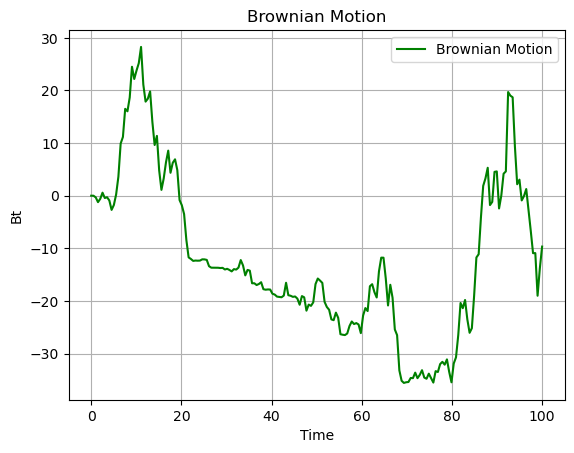

In [37]:

plt.plot(partition, X, linestyle='-', color='g', label='Brownian Motion')


plt.title('Brownian Motion')
plt.xlabel('Time')
plt.ylabel('Bt')


plt.grid(True)
plt.legend()

# Display the final plot
plt.show()

### Exercise 3